In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import joblib
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


In [ ]:
train_df = pd.read_csv("../data/processed/train_all_versions.csv")
val_df = pd.read_csv("../data/processed/val_all_versions.csv")
test_df = pd.read_csv("../data/processed/test_all_versions.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (155551, 8)
Validation shape: (19444, 8)
Test shape: (19444, 8)


In [ ]:
TEXT_COLUMN = "text_ml"
TARGET_COLUMN = "sentiment"   

X_train = train_df[TEXT_COLUMN]
y_train = train_df[TARGET_COLUMN]

X_val = val_df[TEXT_COLUMN]
y_val = val_df[TARGET_COLUMN]

X_test = test_df[TEXT_COLUMN]
y_test = test_df[TARGET_COLUMN]

In [ ]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=1000)) # default is 100 but sometimes it doesnt converge so we use 1000
])


In [ ]:
param_dist = {
    "tfidf__ngram_range": [(1,1), (1,2)], # unigrams and bigrams ( like not good, bi gram example)
    "tfidf__max_features": [50000, 100000, 200000], # limits voacb size, we use large values as text dataset is large
    "tfidf__min_df": [2, 5], # ignore words that appear in less than 2 or 5 documents, helps remove noise
    "tfidf__max_df": [0.9, 0.95], # ignore words that appear in more than 90% or 95% of documents, helps remove common words.
    
    "clf__C": [0.01, 0.1, 1, 10], # for regularization strength, smaller values mean stronger regularization, helps prevent overfitting
    "clf__class_weight": [None, "balanced"], # None means no class weighting, "balanced" means weights are inversely proportional to class frequencies, helps with imbalanced datasets
    "clf__solver": ["lbfgs", "saga"] # optimization algorithms, lbfgs is good for small datasets, saga is good for large datasets and supports l1 regularization
}


In [8]:
print("Missing values in text_ml:", train_df["text_ml"].isnull().sum())
print("Missing values in text_ml (val):", val_df["text_ml"].isnull().sum())
print("Missing values in text_ml (test):", test_df["text_ml"].isnull().sum())

Missing values in text_ml: 94
Missing values in text_ml (val): 8
Missing values in text_ml (test): 11


In [9]:
X_train = X_train.fillna("").astype(str)
X_val = X_val.fillna("").astype(str)
X_test = X_test.fillna("").astype(str)

In [ ]:
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1_macro", # since we have imbalanced dataset, we use f1_macro which gives equal weight to all classes
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("Starting Hyperparameter Tuning............")
random_search.fit(X_train, y_train)


Starting Hyperparameter Tuning............
Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__C': [0.01, 0.1, ...], 'clf__class_weight': [None, 'balanced'], 'clf__solver': ['lbfgs', 'saga'], 'tfidf__max_df': [0.9, 0.95], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be us

In [11]:
print("Best Parameters:\n")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 (Macro):")
print(random_search.best_score_)


Best Parameters:

{'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 5, 'tfidf__max_features': 100000, 'tfidf__max_df': 0.95, 'clf__solver': 'lbfgs', 'clf__class_weight': 'balanced', 'clf__C': 10}

Best Cross-Validation F1 (Macro):
0.46674192789614655


In [12]:
best_model = random_search.best_estimator_

y_val_pred = best_model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation F1 (Macro):", f1_score(y_val, y_val_pred, average="macro"))
print("Validation Precision:", precision_score(y_val, y_val_pred, average="macro"))
print("Validation Recall:", recall_score(y_val, y_val_pred, average="macro"))

print("\nClassification Report (Validation):\n")
print(classification_report(y_val, y_val_pred))


Validation Accuracy: 0.5962764863196873
Validation F1 (Macro): 0.46379729860817837
Validation Precision: 0.45573621077465987
Validation Recall: 0.4751058683206438

Classification Report (Validation):

               precision    recall  f1-score   support

     negative       0.25      0.26      0.25      1106
      neutral       0.32      0.38      0.35      2144
     positive       0.39      0.43      0.41      3999
very_negative       0.51      0.56      0.53      1328
very_positive       0.82      0.74      0.78     10867

     accuracy                           0.60     19444
    macro avg       0.46      0.48      0.46     19444
 weighted avg       0.62      0.60      0.61     19444



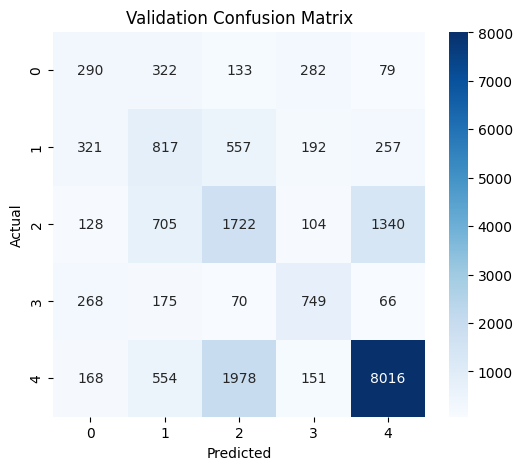

In [13]:
cm_val = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [14]:
y_test_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("Test F1 (Macro):", f1_score(y_test, y_test_pred, average="macro"))
print("Test Precision:", precision_score(y_test, y_test_pred, average="macro"))
print("Test Recall:", recall_score(y_test, y_test_pred, average="macro"))

print("\nClassification Report (Test):\n")
print(classification_report(y_test, y_test_pred))


Test Accuracy: 0.5973050812590002
Test F1 (Macro): 0.4655396965734644
Test Precision: 0.456418175288713
Test Recall: 0.4776865192007125

Classification Report (Test):

               precision    recall  f1-score   support

     negative       0.24      0.27      0.25      1107
      neutral       0.34      0.39      0.36      2144
     positive       0.38      0.42      0.40      3999
very_negative       0.50      0.58      0.54      1328
very_positive       0.82      0.74      0.78     10866

     accuracy                           0.60     19444
    macro avg       0.46      0.48      0.47     19444
 weighted avg       0.62      0.60      0.61     19444



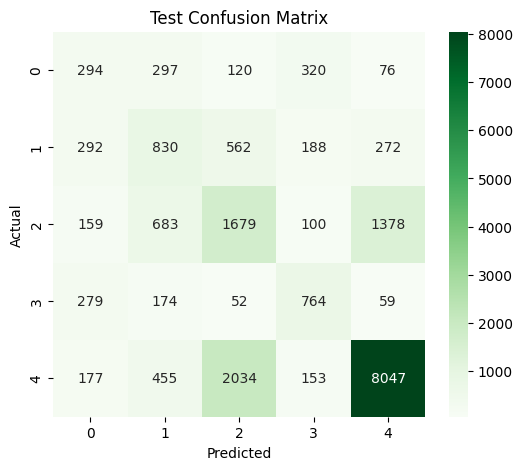

In [15]:
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens")
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
joblib.dump(best_model, "../models/tfidf_logreg_best_model.pkl")

print("Model saved successfully.")
